# ImageNet Classification for the MLA100 NPU chip


## Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.txt imagenet_train20.txt
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.txt imagenet_val20.txt

# Text contains:
# file class_number
# file2 class_number2
# ...

In [3]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.zip imagenet_train20.zip

In [4]:
!unzip -q imagenet_train20.zip
#   inflating: imagenet_train20a/n04346328/n04346328_2302.JPEG
#  inflating: imagenet_train20a/n04346328/n04346328_2842.JPEG

In [5]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.zip imagenet_val20.zip

In [6]:
!unzip -q imagenet_val20.zip

## Install Requirements

In [7]:
!pip -q install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.1 MB/s eta 0:00:00


In [8]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.onnx
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import onnxscript

## Prepare Dataset Loader

In [67]:
IMAGE_ROOT = 'imagenet_train20a'
TRAIN_LIST = 'imagenet_train20.txt'
VAL_IMAGE_ROOT = 'imagenet_val20'
VAL_LIST = 'imagenet_val20.txt'
BATCH_SIZE = 256
NUM_CLASSES = 20
INPUT_SHAPE = (240, 240)
NUM_EPOCHS = 10
LEARNING_RATE = 0.01

In [68]:
class ImageNet20Dataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        self.img_labels = []
        self.root_dir = root_dir
        self.transform = transform
        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    self.img_labels.append((parts[0], int(parts[1])))

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        filename, label = self.img_labels[idx]

        path_flat = os.path.join(self.root_dir, filename)
        path_nested = os.path.join(self.root_dir, filename.split('_')[0], filename)
        full_path = path_flat if os.path.exists(path_flat) else path_nested

        try:
            image = Image.open(full_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (240, 240)) # Fallback if both fail

        if self.transform: image = self.transform(image)
        return image, label



In [69]:
class ReflectiveRotation:
    def __init__(self, degrees, size):
        self.degrees = degrees
        self.size = size

    def __call__(self, img):
        angle = transforms.RandomRotation.get_params([-self.degrees, self.degrees])
        pad_size = int(max(img.size) * 0.5)
        img = transforms.functional.pad(img, pad_size, padding_mode='reflect')
        img = transforms.functional.rotate(img, angle)
        img = transforms.functional.center_crop(img, self.size)
        return img

# alter the training dataset for training
train_transform = transforms.Compose([
    ReflectiveRotation(degrees=25, size=INPUT_SHAPE),
    transforms.RandomResizedCrop(INPUT_SHAPE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

# keep validation unaltered
transform_val = transforms.Compose([
    transforms.Resize(INPUT_SHAPE),
    transforms.ToTensor(),
])

import multiprocessing

# Utilize available CPU cores, leaving a couple free for the OS
num_cores = max(1, multiprocessing.cpu_count() - 2)

train_dataset = ImageNet20Dataset(txt_file=TRAIN_LIST, root_dir=IMAGE_ROOT, transform=train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_cores,
    pin_memory=True,     # Speeds up CPU to GPU memory transfers
    prefetch_factor=2    # Queue up batches in advance
)

print(f"Dataset loaded: {len(train_dataset)} images found.")


val_dataset = ImageNet20Dataset(txt_file=VAL_LIST, root_dir=VAL_IMAGE_ROOT, transform=transform_val)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_cores,
    pin_memory=True
)

print(f"Dataset loaded: {len(val_dataset)} images found.")

Dataset loaded: 6000 images found.
Dataset loaded: 1000 images found.


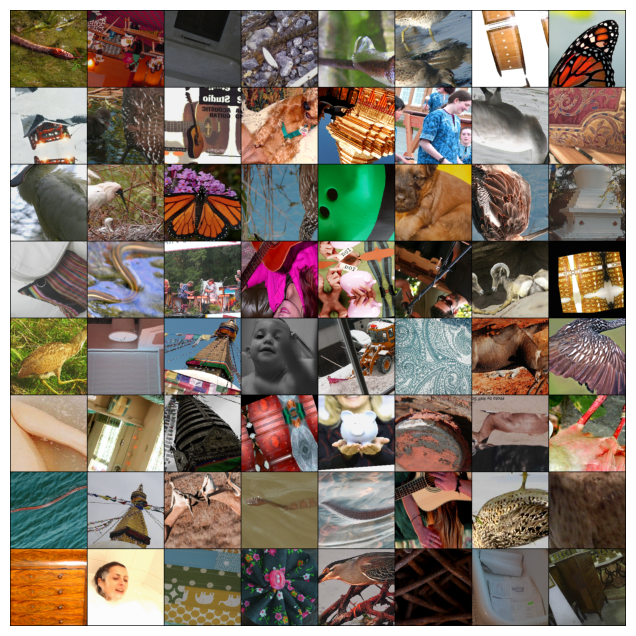

In [70]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

dataiter = iter(train_loader)
images, labels = next(dataiter)

images_to_show = images[:64]

grid_img = torchvision.utils.make_grid(images_to_show, nrow=8, padding=2)

np_img = grid_img.numpy()
formatted_img = np.transpose(np_img, (1, 2, 0))

plt.figure(figsize=(8, 8))
plt.imshow(formatted_img)
plt.axis('off')
plt.show()

# Data Augmentations

In [71]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch

def rand_bbox(size, lam):
    """Generates a dynamic, randomized bounding box based on a lambda value."""
    W = size[2] # Image Width
    H = size[3] # Image Height

    # Calculate the dimensions of the cut based on lambda
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # Choose a completely random center for the box
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    # Calculate the coordinates of the bounding box, ensuring they stay within image bounds
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

# HMix

In [72]:
import torch
import math

def apply_hmix(images, labels, alpha=1.0, r=0.5):
    """
    Fully vectorized H-Mix combining batched continuous mixing and batched discrete masking.
    """
    B, C, H, W = images.shape
    device = images.device

    # 1. Sample Beta distribution on device
    dist = torch.distributions.beta.Beta(alpha, alpha)
    lam_array = dist.sample((B,)).to(device)

    rand_index = torch.randperm(B, device=device)
    target_a = labels
    target_b = labels[rand_index]

    # ==========================================
    # PHASE A: Continuous MixUp Phase
    # ==========================================
    mixup_lams = lam_array / (1.0 - (1.0 - lam_array) * r)
    mix_tensor = mixup_lams.view(B, 1, 1, 1)

    # Create the base faded image for the batch
    base_mix = mix_tensor * images + (1.0 - mix_tensor) * images[rand_index]

    # ==========================================
    # PHASE B: Discrete CutMix Phase
    # ==========================================
    cut_rats = torch.sqrt(1. - lam_array) * math.sqrt(r)
    cut_w = (W * cut_rats).long()
    cut_h = (H * cut_rats).long()

    cx = torch.randint(0, W, (B,), device=device)
    cy = torch.randint(0, H, (B,), device=device)

    bbx1 = torch.clamp(cx - cut_w // 2, 0, W)
    bby1 = torch.clamp(cy - cut_h // 2, 0, H)
    bbx2 = torch.clamp(cx + cut_w // 2, 0, W)
    bby2 = torch.clamp(cy + cut_h // 2, 0, H)

    # Re-using our CutMix broadcasting pattern
    y_grid = torch.arange(H, device=device).view(1, H, 1)
    x_grid = torch.arange(W, device=device).view(1, 1, W)

    mask_y = (y_grid >= bby1.view(B, 1, 1)) & (y_grid < bby2.view(B, 1, 1))
    mask_x = (x_grid >= bbx1.view(B, 1, 1)) & (x_grid < bbx2.view(B, 1, 1))

    # Shape: (B, 1, H, W)
    mask = (mask_y & mask_x).unsqueeze(1).float()

    # 3. Final Compositing: Overwrite the base mix with the pure secondary image inside the mask
    mixed_images = base_mix * (1.0 - mask) + images[rand_index] * mask

    return mixed_images, target_a, target_b, lam_array

# MixUp

In [73]:
import torch

def apply_mixup(images, labels, alpha=1.0):
    """
    Fully vectorized MixUp. Zero CPU-GPU syncing.
    """
    B = images.size(0)
    device = images.device

    # 1. Sample Beta distribution strictly on device
    dist = torch.distributions.beta.Beta(alpha, alpha)
    lam_array = dist.sample((B,)).to(device)

    rand_index = torch.randperm(B, device=device)
    target_a = labels
    target_b = labels[rand_index]

    # 2. Reshape lambda for 4D broadcasting: (B, 1, 1, 1)
    lam_view = lam_array.view(B, 1, 1, 1)

    # 3. Apply continuous mix over the entire batch
    mixed_images = lam_view * images + (1.0 - lam_view) * images[rand_index, :]

    return mixed_images, target_a, target_b, lam_array

# CutMix

In [74]:
def apply_instance_cutmix(images, labels, alpha=1.0):
    B, C, H, W = images.shape
    device = images.device

    # 1. Sample beta distribution directly on device
    dist = torch.distributions.beta.Beta(alpha, alpha)
    lam_array = dist.sample((B,)).to(device)

    rand_index = torch.randperm(B, device=device)
    target_a = labels
    target_b = labels[rand_index]

    # 2. Calculate bounding boxes as tensors
    cut_rats = torch.sqrt(1. - lam_array)
    cut_w = (W * cut_rats).long()
    cut_h = (H * cut_rats).long()

    cx = torch.randint(0, W, (B,), device=device)
    cy = torch.randint(0, H, (B,), device=device)

    bbx1 = torch.clamp(cx - cut_w // 2, 0, W)
    bby1 = torch.clamp(cy - cut_h // 2, 0, H)
    bbx2 = torch.clamp(cx + cut_w // 2, 0, W)
    bby2 = torch.clamp(cy + cut_h // 2, 0, H)

    # 3. Vectorized Mask Creation via Broadcasting
    y_grid = torch.arange(H, device=device).view(1, H, 1)
    x_grid = torch.arange(W, device=device).view(1, 1, W)

    mask_y = (y_grid >= bby1.view(B, 1, 1)) & (y_grid < bby2.view(B, 1, 1))
    mask_x = (x_grid >= bbx1.view(B, 1, 1)) & (x_grid < bbx2.view(B, 1, 1))

    # Shape: (B, 1, H, W)
    mask = (mask_y & mask_x).unsqueeze(1).float()

    # 4. Apply mask in one batched operation
    mixed_images = images * (1.0 - mask) + images[rand_index] * mask

    # Calculate exact lambda
    actual_lam = 1.0 - ((bbx2 - bbx1) * (bby2 - bby1)).float() / (W * H)

    return mixed_images, target_a, target_b, actual_lam

# FMix

In [75]:
import torch
import math

def apply_fmix(images, labels, alpha=1.0, decay_power=3.0):
    """
    Fully vectorized FMix. All operations stay strictly on the accelerator.
    """
    B, C, H, W = images.shape
    device = images.device

    # 1. Sample Beta distribution directly on the device
    dist = torch.distributions.beta.Beta(alpha, alpha)
    lam_array = dist.sample((B,)).to(device)

    rand_index = torch.randperm(B, device=device)
    target_a = labels
    target_b = labels[rand_index]

    # 2. Generate Grid of Frequencies (Shared across batch)
    freqs_x = torch.fft.fftfreq(W, device=device)
    freqs_y = torch.fft.fftfreq(H, device=device)
    fy, fx = torch.meshgrid(freqs_y, freqs_x, indexing='ij')

    # 3. Calculate distance and apply decay
    freq_sq = fx**2 + fy**2
    freq_sq[0, 0] = 1.0  # Prevent division by zero at DC

    amp = 1.0 / (freq_sq ** (decay_power / 2.0))
    amp[0, 0] = 0.0      # Remove DC component

    # Broadcast amplitude to the full batch dimension
    amp = amp.unsqueeze(0).expand(B, H, W)

    # 4. Generate random phase and complex spectrum concurrently
    phase = torch.rand((B, H, W), device=device) * 2 * math.pi
    complex_spec = amp * torch.exp(1j * phase)

    # 5. Inverse FFT (Batched Native PyTorch)
    img = torch.fft.ifft2(complex_spec).real

    # 6. Batched Thresholding (The trickiest part to vectorize)
    img_flat = img.reshape(B, -1)

    # Find the target sort index for each image based on its specific lambda
    idx = torch.clamp(((1.0 - lam_array) * (H * W)).long(), 0, H * W - 1)

    # Sort the flattened spatial dimensions to isolate the threshold values
    sorted_img, _ = torch.sort(img_flat, dim=1)

    # Gather the exact thresholds for the entire batch in one pull
    thresholds = sorted_img[torch.arange(B, device=device), idx].view(B, 1, 1, 1)

    # Broadcast the binary mask: Shape (B, 1, H, W)
    mask = (img.unsqueeze(1) > thresholds).float()

    # 7. Apply the formal mixing equation
    mixed_images = mask * images + (1.0 - mask) * images[rand_index]

    # Recalculate exact lambda based on the discrete mask
    actual_lam = mask.mean(dim=(1, 2, 3))

    return mixed_images, target_a, target_b, actual_lam

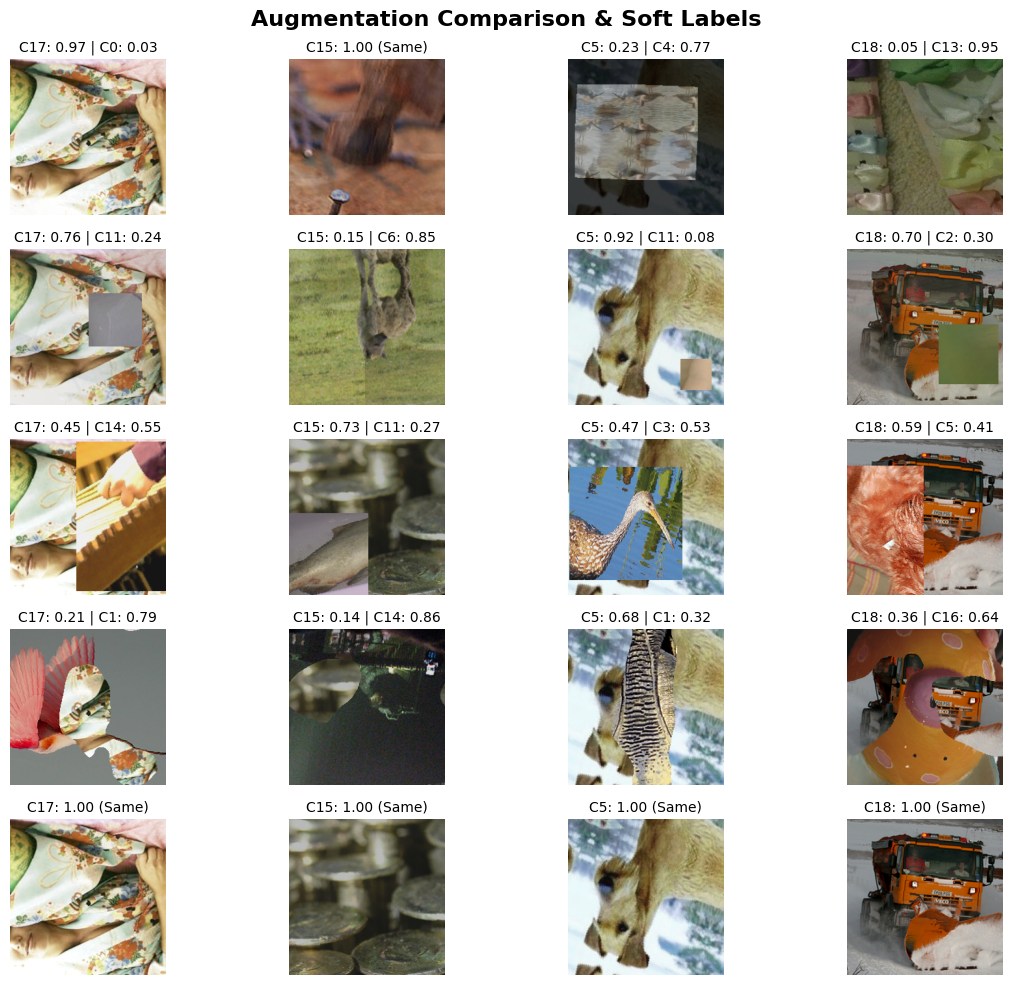

In [76]:
# 1. Grab a single batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 2. Apply all three methods (properly unpacking all 4 returned values)
mixup_imgs, mixup_ta, mixup_tb, mixup_lam = apply_mixup(images, labels)
hmix_imgs, hmix_ta, hmix_tb, hmix_lam = apply_hmix(images, labels)
cutmix_imgs, cutmix_ta, cutmix_tb, cutmix_lam = apply_instance_cutmix(images, labels)
fmix_imgs, fmix_ta, fmix_tb, fmix_lam = apply_fmix(images, labels)

# 3. Setup the plot configuration
configs = [
    ("Mixup", mixup_imgs, mixup_ta, mixup_tb, mixup_lam),
    ("H-Mix", hmix_imgs, hmix_ta, hmix_tb, hmix_lam),
    ("CutMix", cutmix_imgs, cutmix_ta, cutmix_tb, cutmix_lam),
    ("FMix", fmix_imgs, fmix_ta, fmix_tb, fmix_lam),
    ("Reality", images, labels, labels, labels)
]

num_cols = 4
fig, axes = plt.subplots(len(configs), num_cols, figsize=(12, 10))

# 4. Loop through configurations to build a comparative grid
for row_idx, (name, mix_imgs, ta, tb, lam) in enumerate(configs):
    for col_idx in range(num_cols):
        ax = axes[row_idx, col_idx]

        # Format for Matplotlib
        img = mix_imgs[col_idx].numpy()
        img = np.transpose(img, (1, 2, 0))
        img = np.clip(img, 0, 1)

        class_a = ta[col_idx].item()
        class_b = tb[col_idx].item()
        lam_i = lam[col_idx].item()

        ax.imshow(img)
        ax.axis('off')

        if col_idx == 0:
            ax.set_ylabel(name, fontsize=14, fontweight='bold', visible=True)
            # Hack to make ylabel visible without axis lines
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_yticks([])
            ax.set_xticks([])

        title_text = f"C{class_a}: {lam_i:.2f} | C{class_b}: {1 - lam_i:.2f}"
        if class_a == class_b:
            title_text = f"C{class_a}: 1.00 (Same)"

        ax.set_title(title_text, fontsize=10)

plt.suptitle("Augmentation Comparison & Soft Labels", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
import torch
import torch.nn as nn

class NPUModel(nn.Module):
    def __init__(self, num_classes=20):
        super(NPUModel, self).__init__()

        # -----------------------------------------------------------------
        # STAGE 1: STEM (EfficientNetV2 Style)
        # Fast downsampling using a dense Fused-Convolution.
        # -----------------------------------------------------------------
        # Input: (3, H, W) -> Output: (32, H/2, W/2)
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False  # Bias handled by BN
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # -----------------------------------------------------------------
        # STAGE 2: FUSED-MBCONV BLOCK (EfficientNetV2)
        # High FLOPs utilization. We expand, conv, and project.
        # -----------------------------------------------------------------
        # Input: (32, H/2, W/2) -> Output: (64, H/4, W/4)
        self.stage2 = nn.Sequential(
            # Fused Expansion + Downsampling
            nn.Conv2d(
                in_channels=32,
                out_channels=64 * 4, # Expand ratio 4
                kernel_size=3,
                stride=2,            # Downsample here
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64 * 4),
            nn.ReLU(inplace=True),

            # Projection (1x1)
            nn.Conv2d(
                in_channels=64 * 4,
                out_channels=64,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(64)
        )

        # -----------------------------------------------------------------
        # STAGE 3: FASTERNET BLOCK (PConv)
        # Low Latency. Only convolves 1/4 of channels.
        # -----------------------------------------------------------------
        # Input: (64, H/4, W/4) -> Output: (128, H/8, W/8)
        self.stage3_downsample = nn.Sequential(
             nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
             nn.BatchNorm2d(128),
             nn.ReLU(inplace=True)
        )

        # The PConv Block
        self.stage3_pconv = PConvBlock(dim=128, n_div=4)

        # -----------------------------------------------------------------
        # STAGE 4: CONVNEXT / MOBILENETV3 STYLE BLOCK
        # Depthwise Separable Conv for feature refinement.
        # -----------------------------------------------------------------
        # Input: (128, H/8, W/8) -> Output: (256, H/16, W/16)
        self.stage4 = nn.Sequential(
            # 1. Pointwise Expansion
            nn.Conv2d(128, 256, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 2. Depthwise Conv (Spatial mixing) - Stride 2 for downsample
            nn.Conv2d(
                256,
                256,
                kernel_size=3, # Or 5x5/7x7 if NPU supports large kernels
                stride=2,
                padding=1,
                groups=256,    # Depthwise
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 3. Pointwise Projection
            nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256)
        )

        # -----------------------------------------------------------------
        # CLASSIFIER HEAD
        # Fully Convolutional (Linear replaced by Conv2d as requested)
        # -----------------------------------------------------------------
        self.classifier_conv = nn.Conv2d(
            in_channels=256,
            out_channels=num_classes,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=True # True here as it's the final layer (no BN following)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        # x: (N, 3, 240, 240)
        x = self.stem(x)         # -> (N, 32, 120, 120)
        x = self.stage2(x)       # -> (N, 64, 60, 60)

        x = self.stage3_downsample(x) # -> (N, 128, 30, 30)
        x = self.stage3_pconv(x)      # -> (N, 128, 30, 30)

        x = self.stage4(x)       # -> (N, 256, 15, 15)

        # Classification Head
        x = self.classifier_conv(x) # -> (N, 20, 15, 15)
        x = self.global_pool(x)     # -> (N, 20, 1, 1)
        x = x.squeeze(3).squeeze(2) # -> (N, 20)
        return x


class PConvBlock(nn.Module):
    """
    FasterNet Partial Convolution Block.
    Applies Conv only to a split of the channels to save FLOPs.
    """
    def __init__(self, dim, n_div=4):
        super(PConvBlock, self).__init__()
        self.dim_conv3 = dim // n_div
        self.dim_untouched = dim - self.dim_conv3

        # Partial Convolution: Only affects 1/4th of channels
        self.partial_conv = nn.Conv2d(
            in_channels=self.dim_conv3,
            out_channels=self.dim_conv3,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn = nn.BatchNorm2d(self.dim_conv3)
        self.relu = nn.ReLU(inplace=True)

        # Pointwise Mixer (1x1) to mix information across all channels
        self.pw_conv = nn.Conv2d(
            in_channels=dim,
            out_channels=dim,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn_pw = nn.BatchNorm2d(dim)
        self.relu_pw = nn.ReLU(inplace=True)

    def forward(self, x):
        # Slicing for PConv (FasterNet)
        # Note: If NPU does not support slicing, standard Group Conv is the fallback.
        x1 = x[:, :self.dim_conv3, :, :]
        x2 = x[:, self.dim_conv3:, :, :]

        x1 = self.partial_conv(x1)
        x1 = self.bn(x1)
        x1 = self.relu(x1)

        # Concatenate back
        x = torch.cat((x1, x2), dim=1)

        # Pointwise mixing
        x = self.pw_conv(x)
        x = self.bn_pw(x)
        x = self.relu_pw(x)

        return x


In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MixupLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, target_a, target_b, lam):
        loss_a = F.cross_entropy(preds, target_a, reduction='none')
        loss_b = F.cross_entropy(preds, target_b, reduction='none')
        return torch.mean(lam * loss_a + (1 - lam) * loss_b)

class CutMixLabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, preds, target_a, target_b, lam):
        loss_a = F.cross_entropy(preds, target_a, label_smoothing=self.smoothing, reduction='none')
        loss_b = F.cross_entropy(preds, target_b, label_smoothing=self.smoothing, reduction='none')
        return torch.mean(lam * loss_a + (1 - lam) * loss_b)

class FMixKLDivergenceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, preds, target_a, target_b, lam):
        log_probs = F.log_softmax(preds, dim=1)

        target_dist = torch.zeros_like(preds)
        target_dist.scatter_(1, target_a.unsqueeze(1), lam.unsqueeze(1))
        target_dist.scatter_add_(1, target_b.unsqueeze(1), (1 - lam).unsqueeze(1))

        loss = F.kl_div(log_probs, target_dist, reduction='batchmean')
        return loss

class HMixFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, preds, target_a, target_b, lam):
        probs = F.softmax(preds, dim=1)
        log_probs = F.log_softmax(preds, dim=1)

        pt_a = probs.gather(1, target_a.unsqueeze(1)).squeeze(1)
        pt_b = probs.gather(1, target_b.unsqueeze(1)).squeeze(1)

        focal_weight_a = (1 - pt_a) ** self.gamma
        focal_weight_b = (1 - pt_b) ** self.gamma

        loss_a = -focal_weight_a * log_probs.gather(1, target_a.unsqueeze(1)).squeeze(1)
        loss_b = -focal_weight_b * log_probs.gather(1, target_b.unsqueeze(1)).squeeze(1)

        return torch.mean(lam * loss_a + (1 - lam) * loss_b)

In [79]:
import random
from tqdm import tqdm

# Instantiate our custom formalized losses
loss_mixup = MixupLoss()
loss_cutmix = CutMixLabelSmoothingLoss(smoothing=0.1)
loss_fmix = FMixKLDivergenceLoss()
loss_hmix = HMixFocalLoss(gamma=2.0)

def train_model(model, train_loader, optimizer, epochs=NUM_EPOCHS):
    model.train()

    # Pre-define loss functions
    criterions = {
        'mixup': MixupLoss(),
        'cutmix': CutMixLabelSmoothingLoss(smoothing=0.1),
        'fmix': FMixKLDivergenceLoss(),
        'hmix': HMixFocalLoss(gamma=2.0)
    }

    for epoch in range(epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        current_epoch_method = random.choice(['fmix', 'fmix', 'fmix', 'fmix'])
        criterion = criterions[current_epoch_method]

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [{current_epoch_method.upper()}]")

        for images, labels in progress_bar:
            # Move memory explicitly pinned by the dataloader
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Operations happen strictly on the accelerator now
            if current_epoch_method == 'cutmix':
                mixed_images, target_a, target_b, lam = apply_instance_cutmix(images, labels)
            elif current_epoch_method == 'mixup':
                mixed_images, target_a, target_b, lam = apply_mixup(images, labels)
            elif current_epoch_method == 'fmix':
                mixed_images, target_a, target_b, lam = apply_fmix(images, labels)
            elif current_epoch_method == 'hmix':
                mixed_images, target_a, target_b, lam = apply_hmix(images, labels)

            optimizer.zero_grad(set_to_none=True) # Slightly faster than standard zero_grad()

            outputs = model(mixed_images)
            loss = criterion(outputs, target_a, target_b, lam)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            dominant_target = torch.where(lam > 0.5, target_a, target_b)
            correct_predictions += (predicted == dominant_target).sum().item()
            total_samples += images.size(0)

            progress_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

        epoch_loss = running_loss / total_samples
        print(f"\nEpoch {epoch+1} Summary -> Loss: {epoch_loss:.4f}, Acc: {(100 * correct_predictions / total_samples):.2f}%")

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NPUModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_model(model, train_loader, optimizer, epochs=NUM_EPOCHS)

Epoch 1/10 [FMIX]: 100%|██████████| 24/24 [00:27<00:00,  1.15s/it, Loss=2.3029]



Epoch 1 Summary -> Loss: 2.3901, Acc: 13.27%


Epoch 2/10 [FMIX]: 100%|██████████| 24/24 [00:24<00:00,  1.04s/it, Loss=2.2687]



Epoch 2 Summary -> Loss: 2.2494, Acc: 17.78%


Epoch 3/10 [FMIX]: 100%|██████████| 24/24 [00:24<00:00,  1.03s/it, Loss=2.1148]


...


Epoch 6 Summary -> Loss: 2.0689, Acc: 25.32%


Epoch 7/10 [FMIX]: 100%|██████████| 24/24 [00:24<00:00,  1.04s/it, Loss=2.0985]



Epoch 7 Summary -> Loss: 2.0494, Acc: 26.77%


Epoch 8/10 [FMIX]:   0%|          | 0/24 [00:03<?, ?it/s]


KeyboardInterrupt: 